# Tutorial 4 · Train a spiking network

**What you'll learn.** How to turn a spiking network into a trainable model:
plug a surrogate gradient into the spiking nonlinearity, run the network over
time with `for_loop`, and take gradient-descent steps with an optimizer.

**Who it's for.** Readers who have built a network (tutorials 1–3) and now want
to *train* it. (Audience: training / brain-inspired computing.)

The spike threshold is a step function, so its derivative is zero almost
everywhere — vanilla backprop would see no gradient. The fix is a **surrogate
gradient**: the forward pass still emits hard spikes, but the backward pass uses
a smooth surrogate derivative. In `brainpy.state` you simply pass a
`braintools.surrogate` function as `spk_fun=`. The rest is ordinary deep-learning
machinery, with one twist: the per-step `for_loop` is differentiable, so
gradients flow backward through time (BPTT) automatically.

To keep this notebook self-contained we train on a small synthetic
classification task rather than downloading a dataset. The same recipe scales to
MNIST / Fashion-MNIST — see the gallery scripts.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A feed-forward spiking classifier

Three stages: an input→recurrent synapse (a linear layer feeding an exponential
synapse), a recurrent LIF layer whose `spk_fun` is the surrogate, and a
readout→output synapse. Calling the network once advances every stage by one
time step.

In [2]:
class SNN(brainstate.nn.Module):
    def __init__(self, n_in, n_rec, n_out):
        super().__init__()
        self.i2r = brainstate.nn.Sequential(
            brainstate.nn.Linear(
                n_in, n_rec,
                w_init=braintools.init.KaimingNormal(unit=u.mA),
                b_init=braintools.init.ZeroInit(unit=u.mA)),
            brainpy.state.Expon(
                n_rec, tau=5. * u.ms,
                g_initializer=braintools.init.Constant(0. * u.mA)),
        )
        # the surrogate gradient lives here, on the spiking layer
        self.r = brainpy.state.LIF(
            n_rec, tau=20. * u.ms,
            V_rest=0. * u.mV, V_reset=0. * u.mV, V_th=1. * u.mV,
            spk_fun=braintools.surrogate.ReluGrad(),
        )
        self.r2o = brainstate.nn.Linear(
            n_rec, n_out, w_init=braintools.init.KaimingNormal())
        self.o = brainpy.state.Expon(
            n_out, tau=10. * u.ms,
            g_initializer=braintools.init.Constant(0.))

    def update(self, spike):
        return self.o(self.r2o(self.r(self.i2r(spike))))

## A synthetic dataset

Each sample is a `[T, B, n_in]` tensor of Poisson input spikes; the label is a
random binary class. The network's job is to map the spike pattern to its class.

In [3]:
with brainstate.environ.context(dt=1.0 * u.ms):
    n_in, n_rec, n_out = 100, 4, 2
    num_step, num_sample = 200, 256
    freq = 5. * u.Hz

    x_data = brainstate.random.rand(num_step, num_sample, n_in) < freq * brainstate.environ.get_dt()
    x_data = x_data.astype(float)
    y_data = u.math.asarray(brainstate.random.rand(num_sample) < 0.5, dtype=int)

print('inputs:', x_data.shape, '  labels:', y_data.shape)

inputs: (200, 256, 100)   labels: (256,)


## Loss, optimizer, and a compiled train step

The loss runs the network over all time steps with `for_loop`, averages the
output over time, and applies a cross-entropy. The train step is JIT-compiled and
takes one gradient step; the **outer epoch loop is an ordinary Python loop** —
that is fine, because each iteration calls the compiled step. (The rule is never
to time-step a *model* with a bare Python loop, which we don't: time-stepping
goes through `for_loop`.)

In [4]:
with brainstate.environ.context(dt=1.0 * u.ms):
    net = SNN(n_in, n_rec, n_out)
    optimizer = braintools.optim.Adam(lr=3e-3)
    optimizer.register_trainable_weights(net.states(brainstate.ParamState))

    def loss_fn():
        preds = brainstate.transform.for_loop(net.update, x_data)   # [T, B, C]
        preds = u.math.mean(preds, axis=0)                          # [B, C]
        return braintools.metric.softmax_cross_entropy_with_integer_labels(
            preds, y_data).mean()

    @brainstate.transform.jit
    def train_step():
        brainstate.nn.init_all_states(net, batch_size=num_sample)
        grads, loss = brainstate.transform.grad(
            loss_fn, net.states(brainstate.ParamState), return_value=True)()
        optimizer.update(grads)
        return loss

    losses = []
    for epoch in range(1, 201):           # outer optimization loop — OK
        losses.append(float(train_step()))

print('first loss: %.4f   last loss: %.4f' % (losses[0], losses[-1]))

first loss: 0.6931   last loss: 0.5738


## The training curve

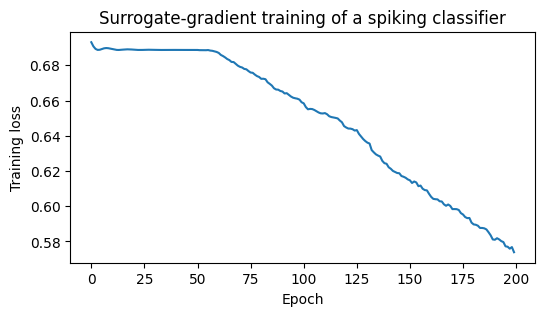

In [5]:
plt.figure(figsize=(6, 3))
plt.plot(np.asarray(losses))
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Surrogate-gradient training of a spiking classifier')
plt.show()

## See also

- :doc:`/concepts/differentiability` — surrogate gradients and BPTT through the
  transform loops, in depth.
- :doc:`../howto/train-surrogate-gradients` — compare different surrogate
  functions.
- :doc:`../howto/train-readouts` — use a `LeakyRateReadout` head instead of
  averaging.
- :doc:`../howto/train-long-rollouts-checkpoint` — bound memory for long
  rollouts with `checkpointed_for_loop`.